# Ramsey model with endogenous labour supply

**Table of contents**<a id='toc0_'></a>    
- 1. [Model description](#toc1_)    
- 2. [Analytical solution](#toc2_)    
- 3. [Numerical solution](#toc3_)    
- 4. [Further analysis](#toc4_)    
- 5. [Conclusion](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

Imports and set magics:

In [50]:
import numpy as np
from scipy import optimize
import sympy as sm

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# local modules
import modelproject_mat

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. <a id='toc1_'></a>[Model description](#toc0_)

The following model is an extension of the RCK model presented in the lectures. It expands the utility maximization problem by adding labour as a choice variable. This will in turn produce another euler namely the intertemporal optimal leisure euler equation.  

**Households**, the model is an extension of RCK model, with discrete time, and an infinitely lived number of finite homogenious agents. We have introduced endogenous labor supply, normalized for each household such that $l_t + n_t = 1$. The representative household have the following instantaneous utility function: 
$$
u(c,n) = \frac{c^{1-\theta}}{1-\theta}-\upsilon \frac{n^{1-\gamma}}{1-\gamma}
$$
With the second element representing disutility from spending time working instead of leisure. 

The social planner face the following problem of maximizing the aggregate utility: 

$$ 
\begin{aligned}
U_0 & =\max_{\{c_{t},n_t\}_{t=0}^{\infty}}\sum_{t=0}^{\infty} \beta^t \left(\frac{C_t^{1-\theta}}{1-\theta}+\upsilon \frac{N_t^{1+\gamma}}{1+\gamma}\right),\beta\in(0,1),\theta > 0,\gamma>0\\
 & \text{s.t.}\\
 & A_{t}+C_t=(1+r_{t})A_{t-1}+w_{t}N_{t} \\
 & L_t + N_t = 1
\end{aligned}
$$

With the lagrangian: 

$$ 
\mathcal{L} = \sum_{t=0}^{\infty} \beta^t \left(\frac{C_t^{1-\theta}}{1-\theta}-\upsilon \frac{N_t^{1-\gamma}}{1-\gamma}\right) + \lambda() 
$$

**Firms** rent capital $K_{t-1}$ at rental rate $r_t^k$ and hires labor $L_t$ at the wage rate $w_t$, with cobb-douglas production technology, such that: 

$$ Y_t = F(K_{t-1},n_t) = B_tK_{t-1}^\alpha n_t^{1-\alpha}, \hspace{0.2in} 0< \alpha < 1, B_t > 0$$

With the profit being defined as: 

$$ \Pi_t = Y_t - w_t N_t - r_t^K K_{t-1}$$

**Equilibrium**: 

1. Households maxmize utility with respect to consumption and labor. 
2. Firms maximize profits with respect to input factors. 
3. The labor market clears such that $N_t = 1-L_t$
4. The goods market clears such that $Y_t = C_t + I_t$
5. The capital market clears such that $A_t = K_t$
6. Capital follows its law of motion $K_t = (1-\delta)K_{t-1}+ I_t$

**Utility maximization, implies**: 

The consumption euler: 
$$ C_t^{-\theta} = \beta (1+r_{t+1}) C_{t+1}^{-\theta}$$

The intratemporal condition: 

$$ -\upsilon N_t^{\gamma} = C_t^{-\theta} \cdot w_t  $$

$$ N_t= \left(\frac{C_t^{-\theta} * w_t}{\upsilon}\right)^{\frac{1}{\gamma}}  $$

$$ -\upsilon N_t/C_t = w_t$$


**Firms FOC from profitmaximization, implies**: 

$$ 
\begin{aligned}
    \frac{\partial \Pi}{\partial K_{t-1}} = \frac{\partial Y_t}{\partial K_{t-1}}-r_t^K \leftrightarrow r_t^K = \alpha K_{t-1}^{\alpha-1}L_t^{1-\alpha}=\alpha k_t^{\alpha-1} \\
    \\
    \frac{\partial \Pi}{\partial n_{t}} = \frac{\partial Y_t}{\partial n_{t}}-w_t \leftrightarrow w_t = (1-\alpha)k_t^{\alpha}
\end{aligned}
$$

https://macrosimulation.org/a_ricardian_one_sector_model

## 2. <a id='toc2_'></a>[Analytical solution](#toc0_)

If your model allows for an analytical solution, you should provide here.

You may use Sympy for this. Then you can characterize the solution as a function of a parameter of the model.

To characterize the solution, first derive a steady state equation as a function of a parameter using Sympy.solve and then turn it into a python function by Sympy.lambdify. See the lecture notes for details. 

## 3. <a id='toc3_'></a>[Numerical solution](#toc0_)

You can always solve a model numerically. 

Define first the set of parameters you need. 

Then choose one of the optimization algorithms that we have gone through in the lectures based on what you think is most fitting for your model.

Are there any problems with convergence? Does the model converge for all starting values? Make a lot of testing to figure these things out. 

In [51]:
model = modelproject_mat.RamseyModelClass()
par = model.par
ss = model.ss
path = model.path

initializing the model:
calling .setup()
calling .allocate()


In [56]:
model.find_steady_state(KY_ss=4.0, N=0.2)

Y_ss = 1.0000
K_ss/Y_ss = 4.0000
rk_ss = 0.0750
r_ss = 0.0250
w_ss = 3.5000
ss_N = -0.2500
Gamma = 2.0355
beta = 0.9756


In [55]:
model.find_steady_state(KY_ss=4.0, N=0.5)

Y_ss = 1.0000
K_ss/Y_ss = 4.0000
rk_ss = 0.0750
r_ss = 0.0250
w_ss = 1.4000
ss_N = -0.2500
Gamma = 1.0718
beta = 0.9756


In [38]:
# a. set initial value
par.K_lag_ini = ss.K

# b. set path
path.Gamma[:] = ss.Gamma
path.C[:] = ss.C
path.K[:] = ss.K

# c. check errors
errors_ss = model.evaluate_path_errors()
assert np.allclose(errors_ss,0.0)

AttributeError: 'types.SimpleNamespace' object has no attribute 'Gamma'

In [ ]:
model.calculate_jacobian()

## 4. <a id='toc4_'></a>[Further analysis](#toc0_)

Make detailed vizualizations of how your model changes with parameter values. 

Try to make an extension of the model. 

## 5. <a id='toc5_'></a>[Conclusion](#toc0_)

Add concise conclusion. 

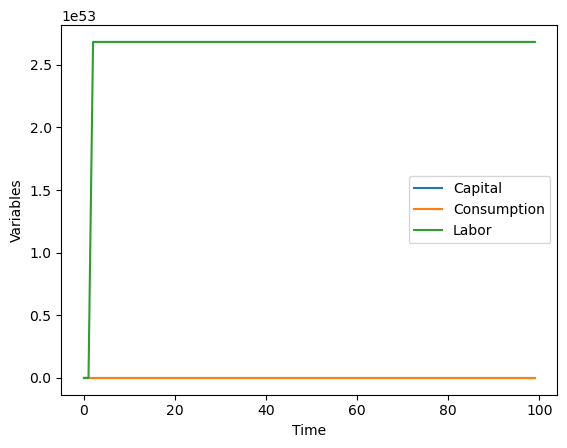

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Parameters
alpha = 0.3  # Capital share
beta = 0.9   # Discount factor
delta = 0.1  # Depreciation rate
gamma = 1    # Frisch elasticity of labor supply

# Production function
def production_function(k, l):
    return k**alpha * l**(1 - alpha)

# Utility function with endogenous labor supply
def utility_function(c, l):
    return np.log(c) - (l**(1 + (1/gamma)) / (1 + (1/gamma)))

# Euler equation
def euler_equation(x, *args):
    k, c_next = x
    beta, alpha, delta, gamma, w, r = args
    l = labor_supply(c_next)
    return -(1 + r - delta) * c_next + (alpha * production_function(k, l)) / c_next

# Labor supply function
def labor_supply(c):
    return ((1 + (1/gamma)) * c)**(1/gamma)

# Solve for optimal consumption and labor supply
def solve_household_problem(k, w, r):
    args = (beta, alpha, delta, gamma, w, r)
    result = minimize(euler_equation, [k, 0.5], args=args, bounds=[(0, None), (0, None)])
    return result.x[0], labor_supply(result.x[1])

# Simulation
def simulate_model(T, k0, w_series, r_series):
    k_path = np.zeros(T)
    l_path = np.zeros(T)
    c_path = np.zeros(T)
    k_path[0] = k0
    for t in range(1, T):
        k, l = solve_household_problem(k_path[t-1], w_series[t], r_series[t])
        k_path[t] = k
        l_path[t] = l
        c_path[t] = production_function(k, l) + (1 - delta) * k - k_path[t]
    return k_path, c_path, l_path

# Parameters for simulation
T = 100
k0 = 0.1
w_series = np.ones(T)  # Wage series
r_series = np.ones(T)  # Interest rate series

# Simulate the model
k_path, c_path, l_path = simulate_model(T, k0, w_series, r_series)

# Plot results
plt.plot(range(T), k_path, label='Capital')
plt.plot(range(T), c_path, label='Consumption')
plt.plot(range(T), l_path, label='Labor')
plt.xlabel('Time')
plt.ylabel('Variables')
plt.legend()
plt.show()